Week 3 :  Customer Intelligence System using Clustering and Segmentation.

*   Objective : Develop a Customer intelligence and Segmentation system using clustering techniques to identify meaningful country segments, analyze socio-economic development patterns, evaluate cluster quality,validate cluster predictions and generate data-driven insights for development prioritization.
*   Techniques used : K-Means Clustering, DBSCAN Clustering, PCA, Silhouette Analysis, Standard Scaling, Random Forest Classification and Feature Importance Analyis.





Step 1 : Import Libraries

In [26]:
#Data Manipulation
import numpy as np
import pandas as pd
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessing
from sklearn.preprocessing import StandardScaler
#Clustering Algorithm
from sklearn.cluster import KMeans, DBSCAN
#Dimensionality Reduction
from sklearn.decomposition import PCA
#Evaluation Metrics
from sklearn.metrics import silhouette_score
#Notebook Configuration
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:2f}")

Step 2 : Load the Dataset

In [3]:
from google.colab import drive
drive.mount("/content/drive")
path='/content/drive/My Drive/Colab Notebooks/Country-data.csv'
df=pd.read_csv(path)

Mounted at /content/drive


Step 3 : Data Inspection

*   The dataset is inspected to understand its structure, dimensions, Feature types, and statistical properties before performing data cleaning and preprocessing.



3.1 Dataset Shape

In [4]:
print("Dataset Shape", df.shape)


Dataset Shape (167, 10)


Observation

*   The dataset contains 167 countries and 10 socio-economic indicators that will be used for clustering analysis.



3.2 First Five Records

In [5]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.200000,10.000000,7.580000,44.900000,1610,9.440000,56.200000,5.820000,553
1,Albania,16.600000,28.000000,6.550000,48.600000,9930,4.490000,76.300000,1.650000,4090
2,Algeria,27.300000,38.400000,4.170000,31.400000,12900,16.100000,76.500000,2.890000,4460
3,Angola,119.000000,62.300000,2.850000,42.900000,5900,22.400000,60.100000,6.160000,3530
4,Antigua and Barbuda,10.300000,45.500000,6.030000,58.900000,19100,1.440000,76.800000,2.130000,12200


Observation:

*   The dataset consists of one categorical feature (country name) and multiple numerical indicators related to economic development, health, and population characterstics .



3.3 Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


Observation

*   The dataset contains one object-type feature (country) and nine numerical features that can be used for clustering after preprocessing.



3.4 Summary Statistics

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country,167,167,Afghanistan,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
child_mort,167.000000,NaN,NaN,NaN,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,NaN,NaN,NaN,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,NaN,NaN,NaN,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,NaN,NaN,NaN,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,NaN,NaN,NaN,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,NaN,NaN,NaN,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,NaN,NaN,NaN,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,NaN,NaN,NaN,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,NaN,NaN,NaN,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


Observations


*   Significant variation exists across health and economic indicators.
*   Income, GDP, and life expectancy differ considerably between countries.
*   The diversity of socio-economic features makes the dataset suitable for clustering analysis .





3.5 Missing Values

In [8]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


Observation

*   No missing values were found in the dataset, indicating good data quality for clustering analysis.



3.6 Duplicate Records

In [9]:
print("Dupicate Records:", df.duplicated().sum())

Dupicate Records: 0


Observation


*   No duplicate records were detected in the dataset



In [10]:
df.columns.tolist()

['country',
 'child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

Step 4 : Data Cleaning

*   Data Cleaning is performed to ensure consistency and quality before Clustering . This includes standardizing column names, removing duplicates, validating numerical features, and handling missing values.



In [11]:
df = df.copy()
#Standardize column names
df.columns = [c.strip().lower() for c in df.columns]
#Remove duplicates
df = df.drop_duplicates()
#Convert numerical columns
for col in df.columns:
  if col != 'country':
    df[col] = pd.to_numeric(df[col], errors='coerce')
#Handling missing values
numerical_cols = [col for col in df.columns if col != 'country' ]
df[numerical_cols] = df[numerical_cols].fillna(
    df[numerical_cols].median()
)
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


Observation:


*   The datset was successfully cleaned and validated . No missing values or duplicate records remain, and all socio-economic indicators are availabe in numerical format for clustering analysis.




Step 5 : Exploratory Data Analyis

*   The EDA is performed to understand the relationships among socio-economic indicators and identify patterns that may influence clustering outcomes.



5.1 Correlation Heatmap

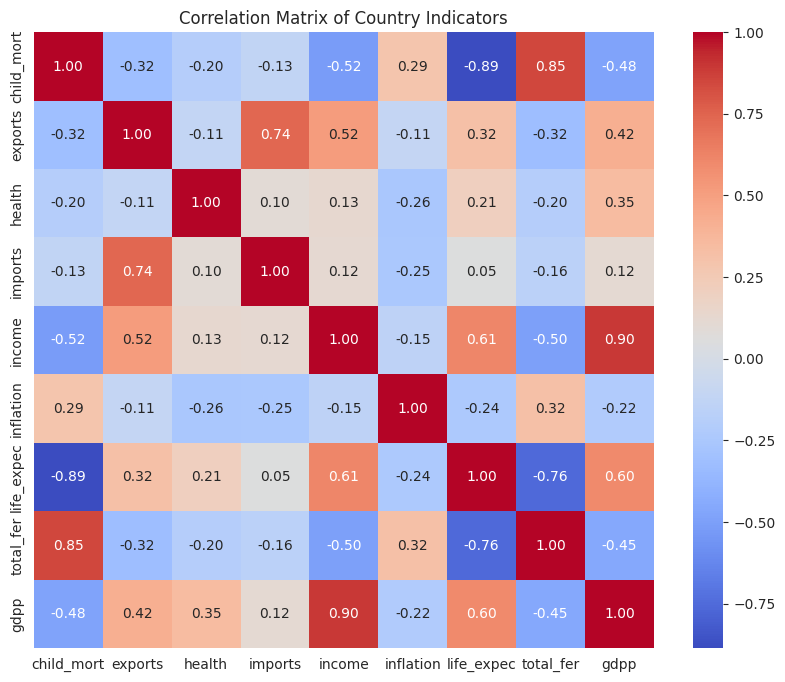

In [12]:
plt.figure(figsize=(10,8))
corr_matrix = df.drop('country', axis=1).corr()
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix of Country Indicators')
plt.show()

Observations:


*   Income and GDP per capita show a very strong positive correlation (0.90), indicating that wealthier countries tend to have higher economic output.
*   Child mortality has a strong negative correlation with life expectancy (-0.89), suggesting that countries with better healthcare systems generally experience longer lifespans.
*   Total fertility rate is positively correlated with child mortality (0.85) and negatively correlated with life expectancy (-0.76), reflecting developmental differences across countries.
*   These strong relationships indicate the presence of distinct socio-economic groups, making the datset highly suitable for clustering analysis.




5.2 Country Development Indicators Distribution

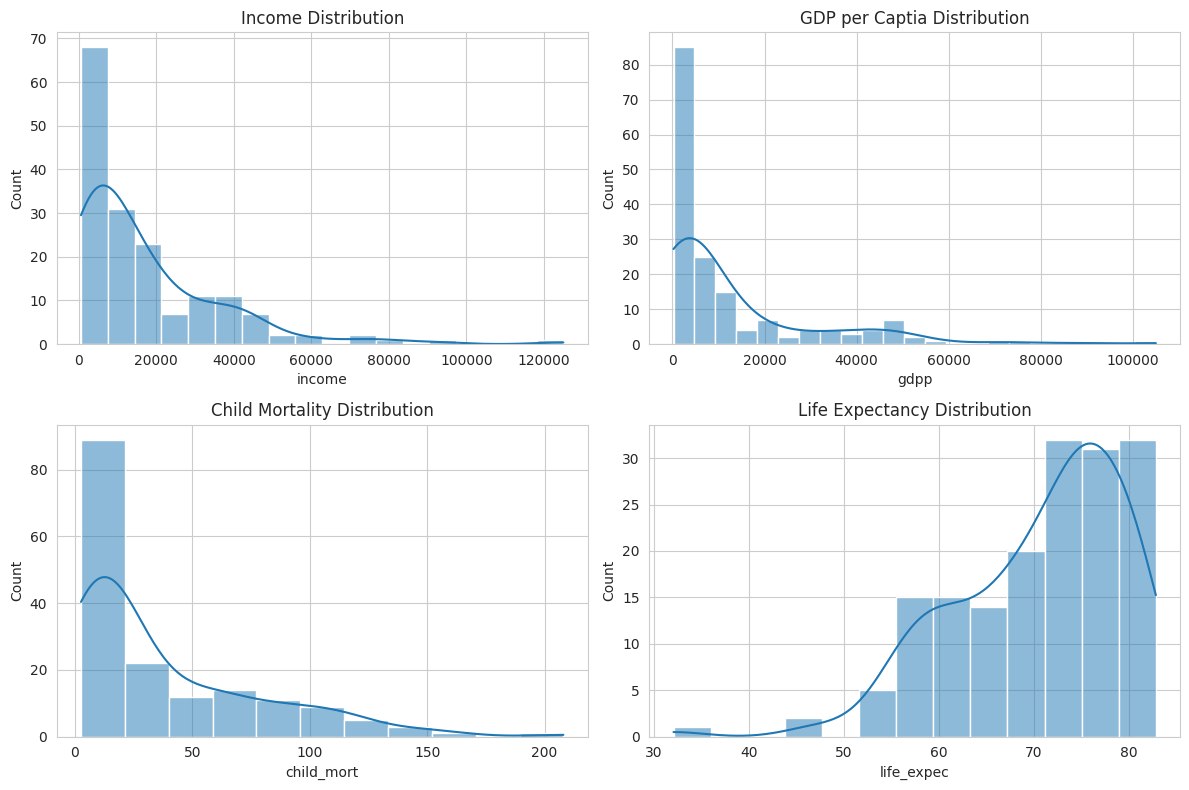

In [13]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
sns.histplot(df['income'], kde=True, ax=axes[0,0])
axes[0,0].set_title("Income Distribution")
sns.histplot(df['gdpp'], kde=True, ax=axes[0,1])
axes[0,1].set_title("GDP per Captia Distribution")
sns.histplot(df['child_mort'], kde=True, ax=axes[1,0])
axes[1,0].set_title("Child Mortality Distribution")
sns.histplot(df['life_expec'], kde=True, ax=axes[1,1])
axes[1,1].set_title("Life Expectancy Distribution")
plt.tight_layout()
plt.show()

Observations

*   Income, GDP per captia, and child mortality exhibit right-skewed distributions, indicating substantial disparities among countries.
*   Life expectancy is concentrated at higher values, suggesting that most countries achieve moderate to high longevity levels.
*   The variation across these indicators supports the existence of distinct country segments suitable for clustering.




5.3 Box Plot

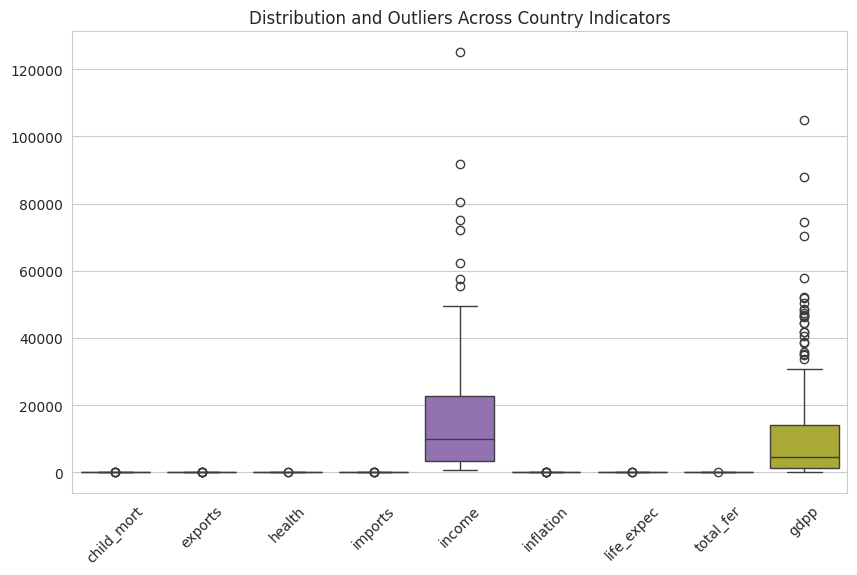

In [14]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.drop('country', axis=1))
plt.title("Distribution and Outliers Across Country Indicators")
plt.xticks(rotation=45)
plt.show()

Observations

*   Income and GDP per captia exhibit several extreme values, indicating substantial economic disparities among countries .
*   Multiple indicators are measured on different scales, which can bias distance-based clustering algorithm.
*   Therefore, feature scaling is required before applying K-Means and DBSCAN





Step 6 : Feature Scaling

In [15]:
#Preserve country names
countries = df['country']
#select numerical features
X = df.drop('country', axis=1)
#Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


Observation


*   The numerical features were successfully standardized using StandardScaler . All variatbles are now on a comparable scale, preventing high-magnitude features from dominating the clustering process.



Step 7 : K-Means Elbow Method

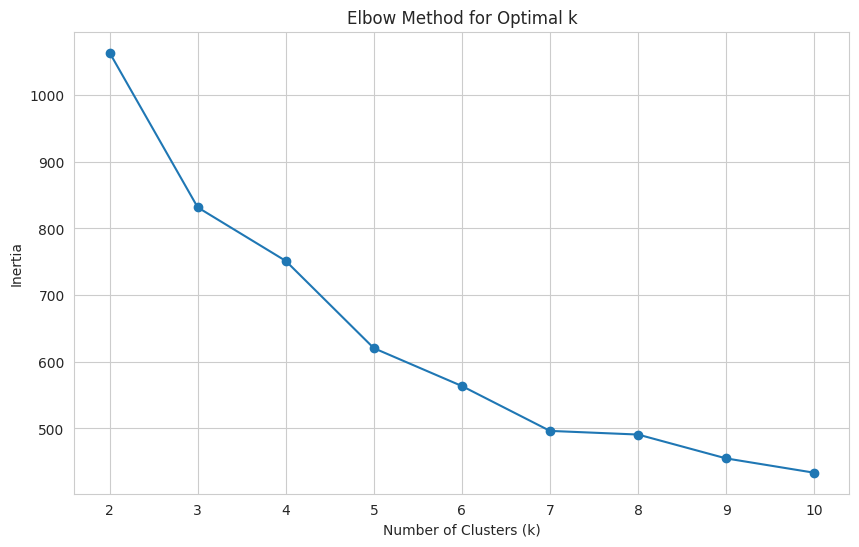

In [16]:
inertias = []
for k in range(2,11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
plt.plot(range(2,11), inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

Observation


*   The inertia decreases significantly as the number of clusters increases from 2 to 5 and begins to stabilize thereafter . Based on the assignment requirement and the elbow trend, k=3 was selected as the baseline number of clusters



Step 8 : K-Means Clustering

In [17]:
best_k = 3
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_scaled)
df['Cluster'] = kmeans_labels
df[['country','Cluster']].head()

,country,Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


Observation


*   The K-Means algorithm successfully segmented countries into three clusters based on similarities in socio-economic and health indicators.



Step 9 : Silhouette Score Evaluation

*   The Silhouette Score was used to evaluate cluster quality by measuring the seperation between clusters and the cohesion within clusters.



In [18]:
from sklearn.metrics import silhouette_score
sil_score = silhouette_score(
    X_scaled,
    df['Cluster']
)
print("Silhouette Score :",round(sil_score,4))

Silhouette Score : 0.2833


Observation


*   The K-Means model achieved a Silhouette Score of 0.2833, indicating moderate cluster seperation. This suggests that countries within each cluster share similar socio-economic characterstics, while some overlap exists between clusters due to complexity of real-world development patterns .



Step 10 : DBSCAN

In [19]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)
df['DBSCAN_Cluster'] = dbscan_labels
print(df['DBSCAN_Cluster'].value_counts().sort_index())

DBSCAN_Cluster
-1    167
Name: count, dtype: int64






*   Observation:


DBSCAN was unable to identify
meaningful density-based clusters in the standardized datset,  indicating that K-Means provide a more suitable clustering approach for this problem .





Step 11 : PCA Preparation and Visualization

11.1 PCA Preparation

In [20]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    pca_features,
    columns=['PC1','PC2']
)
pca_df.head()

,PC1,PC2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


Observation

*   PCA succesfully reduced the nine-dimensional feature space into principal components, enaling visualization of country clusters in a two-dimensional space while preserving the most significant variance in the dataset.



11.2 PCA Visualization

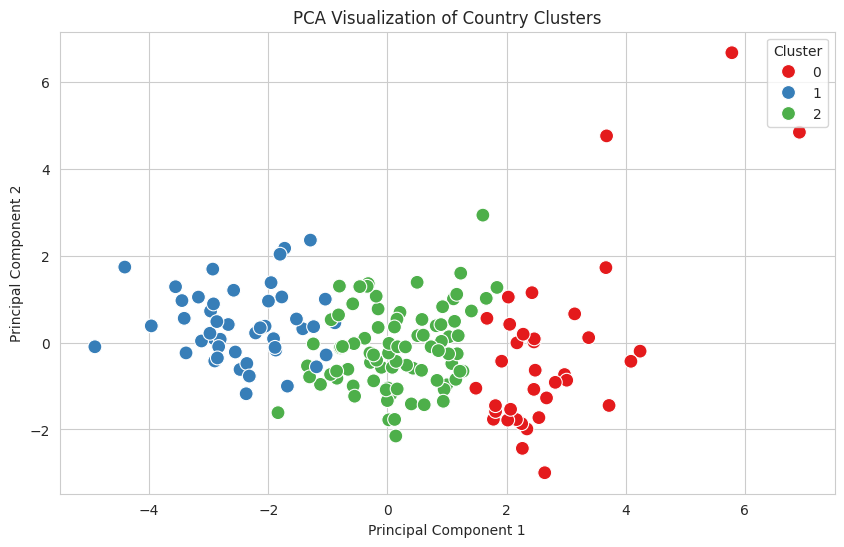

In [21]:
pca_df['Cluster']= df['Cluster']
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)
plt.title("PCA Visualization of Country Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

The PCA scatterplot reveals three distinct country clusters identified by K-Means algorithm.Cluster 0 appears well separated on the positive side of Principal Component 1, while Clusters 1 and 2 occupy different regions of the feature space with limited overlap. The visual seperation indicates that countries within each cluster share similar socio-economic characterstics, supporting the effectiveness of the clustering approach.

Step 12.1 : Cluster Distribution Analysis

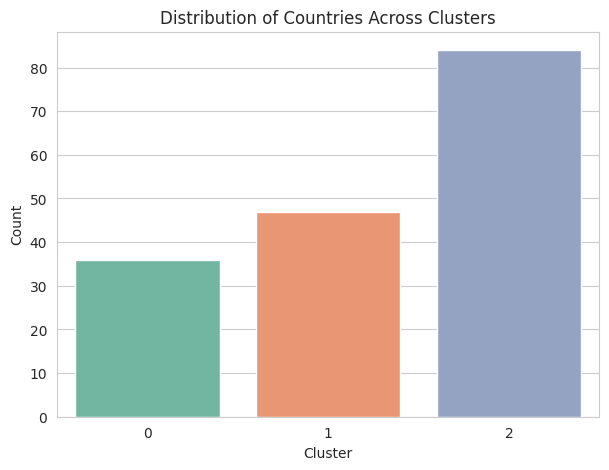

Cluster
0    36
1    47
2    84
Name: count, dtype: int64


In [22]:
plt.figure(figsize=(7,5))
sns.countplot(
    x='Cluster',
    hue='Cluster',
    data=df,
    palette='Set2',
    legend=False
)
plt.title("Distribution of Countries Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()
print(df['Cluster'].value_counts().sort_index())

Observation

*   The cluster distribution analysis show that Cluster 2 contains the highest number of countries (84), followed by Cluster 1 (47) and Cluster 0 (36). This indicates that the majority of countries share similar socio-economic characterstics represented by Cluster 2 , while Clusters 0 and 1 capture more distinct development patterns . The variation in cluster sizes suggests meaningful segmentation of countries based on economic, health and demographic indicators.



Step 12.2 : Cluster Profiling

In [23]:
cluster_profile = df.groupby('Cluster').mean(numeric_only=True)
cluster_profile = cluster_profile.T
cluster_profile

Cluster,0,1,2
child_mort,5.000000,92.961702,21.927381
exports,58.738889,29.151277,40.243917
health,8.807778,6.388511,6.200952
imports,51.491667,42.323404,47.473404
income,45672.222222,3942.404255,12305.595238
inflation,2.671250,12.019681,7.600905
life_expec,80.127778,59.187234,72.814286
total_fer,1.752778,5.008085,2.307500
gdpp,42494.444444,1922.382979,6486.452381
DBSCAN_Cluster,-1.000000,-1.000000,-1.000000


Observation


*   The cluster profiling results reveal significant differences in socio-economic and health indicators across the three clusters. Cluster 0 exhibits the highest income, GDP per captia, and life expectancy, while Cluster 1 shows the highest child mortality and fertility rates. Cluster 2 represents countries with moderate development characterstics .



Step 13 Future Enhancements

*   Random Forest Classifier
*   Feature Importance Analysis

*   These techniques can complement clustering by enabling predictive analytics and improving decision-making through classification-based insights








13.1 Cluster Prediction using Random Forest

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
X = X_scaled
y = df['Cluster']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
rf= RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



13.2 : Feature Importance

In [25]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df

,Feature,Importance
0,child_mort,0.251179
8,gdpp,0.199593
7,total_fer,0.174030
6,life_expec,0.161208
4,income,0.144110
2,health,0.031770
5,inflation,0.016104
3,imports,0.011648
1,exports,0.010357


Observation

*   The Random Forest model achieved 100% classification accuracy in predicting K-Means cluster labels.This indicates that the identified country clusters are highly distinguishable based on the selected socio-economic indicators. The result further validates the effectiveness of the clustering process and demonstrate strong seperability among country groups.

*   Accuracy = 1.00

*  Child mortality, GDP per captia, fertility rate, life expectancy, and income are the most important features influencing country cluster membership. Child mortality has the highest impact, indicating its strong role in differentiating country development levels.







13.3 Feature Importance Plot


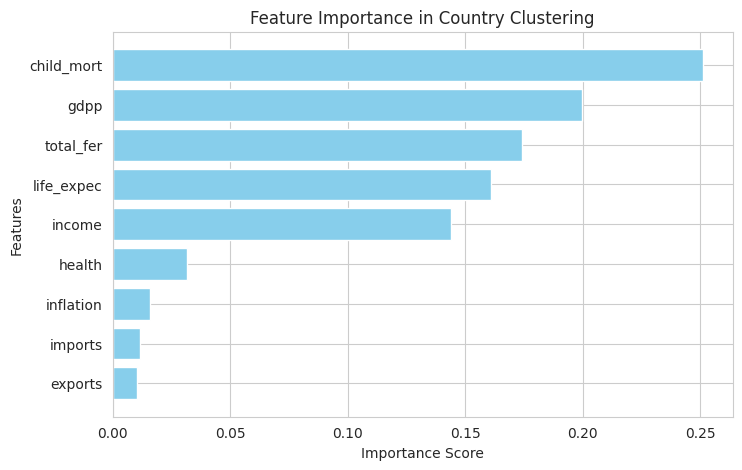

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='skyblue'
)
plt.title("Feature Importance in Country Clustering")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()

Step 14 Final Insights

1.   Which cluster has high child mortality ?
*   Cluster 1 has the highest average child mortality rate(92.96) and the lowest life expectancy (59.19 years), indicating severe healthcare and developmental challenges.

2.   Which cluster has high income and GDP per captia ?
*   Cluster 0 has the highest average income (45672) and GDP per captia income (42494) along with the highest life expectancy (80.13 years). This cluster represents the most economically developed ountries.

3.   Which cluster looks underdeveloped?
*   Cluster 1 appears to be the most underdeveloped group, characterized by low income, low GDP per captia, high fertility rates, and poor health outcomes.

4.   Which countries should be prioritized for aid ?
*   Countries belonging to Cluster 1 should be prioritized for international aid and development programs because they experience the highest child mortality, lowest income levels, and the weakest socio-economic indicators.



5.   Overall Conclusion

*   The clustering analysis successfully identified three distinct groups of countries: developed economies(Cluster 0),underdeveloped economies (Cluster 1), and emerging economies (Cluster 2). The Silhouette Score confirmed reasonable cluster quality, while PCA visualization demonstrated clear seperation between country groups. Additionally, Random Forest validation achieved high predictive perfomance, and feature importance analysis revealed that child mortality, GDP per captia, fertility rate, life expectancy, and income were the key factors influencing country segmentation .








